# Diffusion Models from Gaussian Noise to Denoising Networks

This Colab notebook illustrates the main ideas from the diffusion notes:

1. **Gaussian random-variable arithmetic** behind the forward noising formula  
   
$$
x_t = \sqrt{1-\beta_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon_t,
   \qquad \varepsilon_t \sim \mathcal N(0,I).
$$

2. A **toy 10x10 image model** with rectangles and circles.
3. The difference between:
   - **exact educational inversion** (using the true noise),
   - **stochastic generative reverse** (using estimated noise plus fresh randomness).
4. Training a **small neural network** to predict the noise and denoise toy images.

This notebook is intentionally small and educational. It is not meant to compete with large image diffusion models.

## Learning goals

After running this notebook, students should be able to explain:

- why the forward process is *not* usually learned,
- how the forward process automatically creates training pairs,
- why linear combinations of independent Gaussian random variables are Gaussian,
- what the network is trained to predict,
- why reverse sampling remains stochastic and outputs are not exact copies.

In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from IPython.display import display, Markdown

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Part A. Gaussian arithmetic

If

$$
X \sim \mathcal N(\mu_X,\sigma_X^2), \qquad Y \sim \mathcal N(\mu_Y,\sigma_Y^2)
$$

are independent, then

$$
aX+bY \sim \mathcal N(a\mu_X+b\mu_Y,\; a^2\sigma_X^2+b^2\sigma_Y^2).
$$


This is the probabilistic fact that makes the forward diffusion formulas work.

In diffusion, conditioned on $x_{t-1}$, the vector $x_{t-1}$ is fixed and the only randomness comes from $\varepsilon_t\sim\mathcal N(0,I)$. Therefore

$$
x_t \mid x_{t-1} \sim \mathcal N\!\left(\sqrt{1-\beta_t}\,x_{t-1},\, \beta_t I\right).
$$


In [ ]:
# Empirical scalar check of Gaussian arithmetic
mu_X = 2.0
sigma_X = 1.5
mu_Y = -1.0
sigma_Y = 0.75
a = 1.2
b = -0.8

n = 200_000
X = np.random.normal(mu_X, sigma_X, size=n)
Y = np.random.normal(mu_Y, sigma_Y, size=n)
Z = a * X + b * Y

theory_mean = a * mu_X + b * mu_Y
theory_var = (a**2) * (sigma_X**2) + (b**2) * (sigma_Y**2)

print(f"Theoretical mean: {theory_mean:.4f}")
print(f"Empirical   mean: {Z.mean():.4f}")
print(f"Theoretical var : {theory_var:.4f}")
print(f"Empirical   var : {Z.var():.4f}")

Theoretical mean: 3.2000
Empirical   mean: 3.1999
Theoretical var : 3.6000
Empirical   var : 3.5857


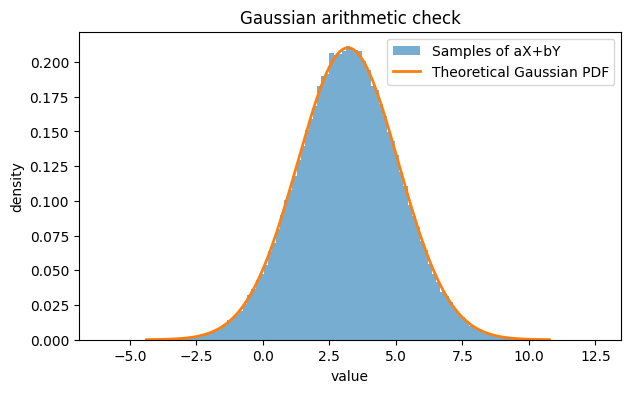

In [ ]:
# Visual check: histogram versus the theoretical Gaussian curve
xs = np.linspace(Z.mean() - 4*Z.std(), Z.mean() + 4*Z.std(), 500)
theory_pdf = (1 / np.sqrt(2*np.pi*theory_var)) * np.exp(-(xs - theory_mean)**2 / (2*theory_var))

plt.figure(figsize=(7,4))
plt.hist(Z, bins=120, density=True, alpha=0.6, label="Samples of aX+bY")
plt.plot(xs, theory_pdf, linewidth=2, label="Theoretical Gaussian PDF")
plt.title("Gaussian arithmetic check")
plt.xlabel("value")
plt.ylabel("density")
plt.legend()
plt.show()

## Part B. Toy 10x10 images

We work with a tiny $10\times 10$ grid. White pixels have value $1$, black pixels have value $0$.

We use two simple shape families:
- rectangles,
- circles.

The point is not realism. The point is that the image is structured enough for students to see how noise destroys and then reconstructs structure.

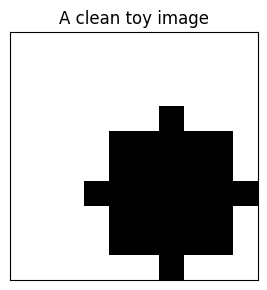

In [ ]:
GRID = 10

def make_rectangle(x0=None, y0=None, w=None, h=None, grid=GRID):
    img = np.ones((grid, grid), dtype=np.float32)
    if w is None: w = np.random.randint(2, 5)
    if h is None: h = np.random.randint(2, 5)
    if x0 is None: x0 = np.random.randint(0, grid - w + 1)
    if y0 is None: y0 = np.random.randint(0, grid - h + 1)
    img[y0:y0+h, x0:x0+w] = 0.0
    return img

def make_circle(cx=None, cy=None, r=None, grid=GRID):
    img = np.ones((grid, grid), dtype=np.float32)
    if r is None: r = np.random.randint(2, 4)
    if cx is None: cx = np.random.randint(r, grid - r)
    if cy is None: cy = np.random.randint(r, grid - r)
    yy, xx = np.mgrid[0:grid, 0:grid]
    mask = (xx - cx)**2 + (yy - cy)**2 <= r**2
    img[mask] = 0.0
    return img

def random_shape(kind="mixed"):
    if kind == "rectangle":
        return make_rectangle()
    if kind == "circle":
        return make_circle()
    return make_rectangle() if np.random.rand() < 0.5 else make_circle()

def show_images(images, titles=None, cmap="gray", vmin=-1.5, vmax=1.5, figsize=(14,3)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        ax = plt.subplot(1, n, i+1)
        ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_xticks([])
        ax.set_yticks([])
        if titles is not None:
            ax.set_title(titles[i])
    plt.tight_layout()
    plt.show()

x0_example = random_shape("mixed")
show_images([x0_example], ["A clean toy image"], figsize=(3,3), vmin=0, vmax=1)

## Part C. One-step and two-step forward diffusion

For one forward step:

$$
x_1 = \sqrt{1-\beta_1}\,x_0 + \sqrt{\beta_1}\,\varepsilon_1.
$$


For two forward steps:

$$
x_2 = \sqrt{1-\beta_2}\,x_1 + \sqrt{\beta_2}\,\varepsilon_2.
$$


Substituting the first formula into the second shows:

$$
x_2
=
\sqrt{(1-\beta_1)(1-\beta_2)}\,x_0
+
\sqrt{(1-\beta_2)\beta_1}\,\varepsilon_1
+
\sqrt{\beta_2}\,\varepsilon_2.
$$


This is again a linear combination of independent Gaussian terms, so it is still Gaussian.

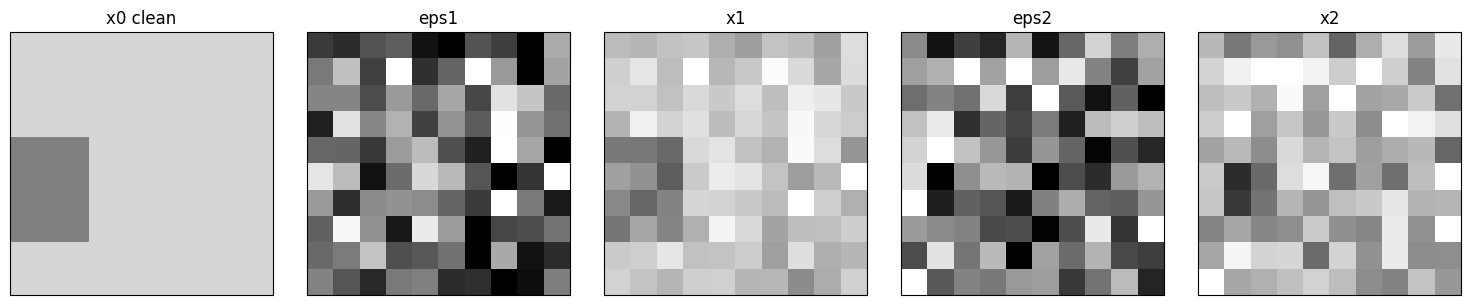

In [ ]:
def forward_step(x_prev, beta, eps=None):
    if eps is None:
        eps = np.random.randn(*x_prev.shape).astype(np.float32)
    x_next = np.sqrt(1 - beta) * x_prev + np.sqrt(beta) * eps
    return x_next, eps

beta1 = 0.10
beta2 = 0.25

x0 = random_shape("rectangle")
x1, eps1 = forward_step(x0, beta1)
x2, eps2 = forward_step(x1, beta2)

show_images(
    [x0, eps1, x1, eps2, x2],
    ["x0 clean", "eps1", "x1", "eps2", "x2"],
    figsize=(15,3)
)

## Part D. Exact inversion versus stochastic reverse

### Exact educational inversion
If we know the **true** noise used in the forward step, then we can exactly invert the algebra:

$$
x_{t-1} = \frac{x_t - \sqrt{\beta_t}\,\varepsilon_t}{\sqrt{1-\beta_t}}.
$$


This is excellent for teaching because students can verify the formulas.

### Stochastic generative reverse
In a real diffusion model, the true noise is not known at sampling time. The model predicts it:

$$
\hat\varepsilon_\theta(x_t,t) \approx \varepsilon_t.
$$


A pedagogical stochastic reverse update is:

$$
\hat x_{t-1}
=
\frac{x_t - \sqrt{\beta_t}\,\hat\varepsilon_\theta}{\sqrt{1-\beta_t}}
+
\sigma_t z,
\qquad z\sim\mathcal N(0,I).
$$


Because of the fresh random term $\sigma_t z$, the output is similar to the original data distribution but not exactly identical.

In [ ]:
# Optional interactive widget section for Colab / Jupyter
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

try:
    import ipywidgets as widgets
    from ipywidgets import interact

    def exact_and_stochastic_demo(shape="rectangle", beta1=0.10, beta2=0.25, sigma=0.10, seed=0):
        np.random.seed(seed)

        x0 = random_shape(shape)
        x1, eps1 = forward_step(x0, beta1)
        x2, eps2 = forward_step(x1, beta2)

        # Exact inversion using the true noises
        x1_exact = (x2 - np.sqrt(beta2) * eps2) / np.sqrt(1 - beta2)
        x0_exact = (x1_exact - np.sqrt(beta1) * eps1) / np.sqrt(1 - beta1)

        # Stochastic reverse using imperfect noise estimates
        eps2_hat = eps2 + sigma * np.random.randn(*eps2.shape).astype(np.float32)
        x1_stoch_mean = (x2 - np.sqrt(beta2) * eps2_hat) / np.sqrt(1 - beta2)
        x1_stoch = x1_stoch_mean + sigma * np.random.randn(*x1.shape).astype(np.float32)

        eps1_hat = eps1 + sigma * np.random.randn(*eps1.shape).astype(np.float32)
        x0_stoch_mean = (x1_stoch - np.sqrt(beta1) * eps1_hat) / np.sqrt(1 - beta1)
        x0_stoch = x0_stoch_mean + sigma * np.random.randn(*x0.shape).astype(np.float32)

        show_images(
            [x0, x1, x2, x0_exact, x0_stoch],
            ["x0", "x1", "x2", "exact reverse", "stochastic reverse"],
            figsize=(14,3)
        )

        print("Educational point:")
        print("- exact reverse nearly reconstructs x0 because it uses the true forward noises")
        print("- stochastic reverse is similar, but not identical, because it uses imperfect noise estimates plus fresh randomness")

    interact(
        exact_and_stochastic_demo,
        shape=widgets.Dropdown(options=["rectangle", "circle"], value="rectangle"),
        beta1=widgets.FloatSlider(min=0.01, max=0.40, step=0.01, value=0.10),
        beta2=widgets.FloatSlider(min=0.01, max=0.40, step=0.01, value=0.25),
        sigma=widgets.FloatSlider(min=0.00, max=0.40, step=0.01, value=0.10),
        seed=widgets.IntSlider(min=0, max=20, step=1, value=0),
    );
except Exception as e:
    print("Widgets not available in this environment.")
    print("Error:", e)

interactive(children=(Dropdown(description='shape', options=('rectangle', 'circle'), value='rectangle'), Float…

## Part E. Forward diffusion schedule used for training

For the learned denoiser, we choose a **milder noise schedule** than before so that the model can learn the toy task more easily.

We use
$$
\beta_1,\beta_2,\dots,\beta_T,
\qquad
\alpha_t = 1-\beta_t,
\qquad
\bar\alpha_t = \prod_{s=1}^t \alpha_s.
$$

Then a noisy training sample is generated by
$$
x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,
\qquad \varepsilon\sim \mathcal N(0,I).
$$

In this notebook we start with **rectangles only** for the learned denoiser, because that makes the denoising effect much easier to see. After that works, you can switch the generator to circles or mixed shapes.


In [ ]:
T = 10
beta_start = 0.01
beta_end = 0.06

betas = torch.linspace(beta_start, beta_end, T, device=device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

print("betas shape:", betas.shape)
print("first five betas:", betas[:5].cpu().numpy())
print("first five alpha_bars:", alpha_bars[:5].cpu().numpy())

betas shape: torch.Size([10])
first five betas: [0.01       0.01555556 0.02111111 0.02666667 0.03222222]
first five alpha_bars: [0.99       0.9746     0.9540251  0.92858446 0.8986634 ]


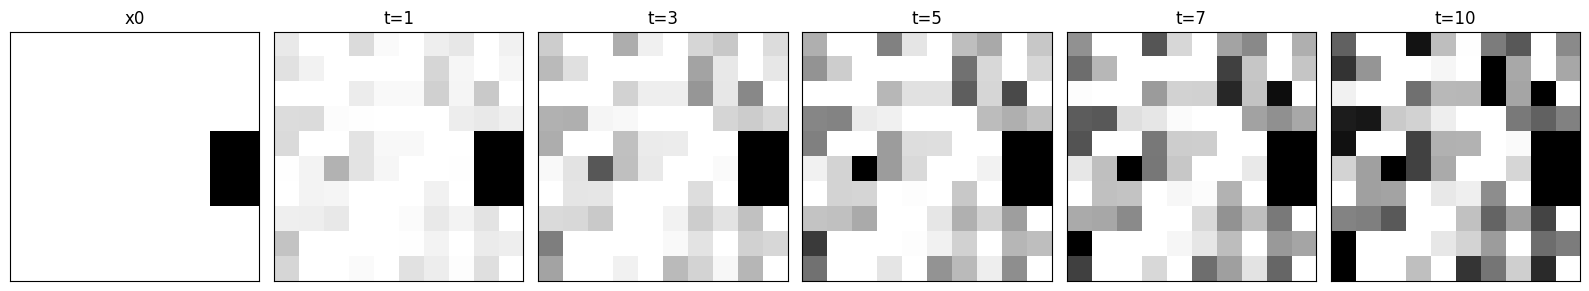

In [ ]:
def make_batch(batch_size=128, kind="rectangle"):
    x0 = np.stack([random_shape(kind) for _ in range(batch_size)]).astype(np.float32)
    x0 = torch.tensor(x0, device=device).view(batch_size, -1)

    t = torch.randint(0, T, (batch_size,), device=device)
    noise = torch.randn_like(x0)

    a_bar = alpha_bars[t].unsqueeze(1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise
    return x0, xt, t, noise

# Quick visual of different noise levels
x0_vis = torch.tensor(random_shape("rectangle"), device=device).view(1, -1)
noise_vis = torch.randn_like(x0_vis)

levels = [0, 2, 4, 6, 9]
frames = [x0_vis.view(GRID, GRID).cpu().numpy()]
titles = ["x0"]

for level in levels:
    a_bar = alpha_bars[level]
    xt = torch.sqrt(a_bar) * x0_vis + torch.sqrt(1 - a_bar) * noise_vis
    frames.append(xt.view(GRID, GRID).cpu().numpy())
    titles.append(f"t={level+1}")

show_images(frames, titles, figsize=(16,3), vmin=0, vmax=1)

## Part F. A tiny denoising neural network

The network receives a noisy image $x_t$ and the time index $t$, and it learns to predict the noise $\varepsilon$.

Because this is only a classroom demo, the model is tiny. To make the denoising effect easier to observe, the default training task uses **rectangles** rather than a more complicated mixed-shape dataset.

If the training result still looks weak on CPU, simply run the training cell for a few more epochs.


In [ ]:
class TinyDenoiser(nn.Module):
    def __init__(self, dim=100, hidden=384, time_embed_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
            nn.SiLU(),
        )
        self.net = nn.Sequential(
            nn.Linear(dim + time_embed_dim, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, dim),
        )

    def forward(self, xt, t):
        t = t.float().unsqueeze(1) / (T - 1)
        te = self.time_mlp(t)
        x = torch.cat([xt, te], dim=1)
        return self.net(x)

model = TinyDenoiser(dim=GRID*GRID).to(device)
model

TinyDenoiser(
  (time_mlp): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): SiLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SiLU()
  )
  (net): Sequential(
    (0): Linear(in_features=164, out_features=384, bias=True)
    (1): SiLU()
    (2): Linear(in_features=384, out_features=384, bias=True)
    (3): SiLU()
    (4): Linear(in_features=384, out_features=384, bias=True)
    (5): SiLU()
    (6): Linear(in_features=384, out_features=100, bias=True)
  )
)

### Training loss

The network is trained by minimizing the mean squared error
$$
L(\theta)=\mathbb E\bigl[\|\varepsilon-\varepsilon_\theta(x_t,t)\|^2\bigr].
$$

In other words, we generate a clean toy image $x_0$, add Gaussian noise to obtain $x_t$, and then ask the network to recover the noise that was added.

After that, we can estimate the clean image by
$$
\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\varepsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}.
$$


In [ ]:
def train_model(model, epochs=10, steps_per_epoch=80, batch_size=128, lr=1e-3, kind="rectangle"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    model.train()
    for epoch in range(epochs):
        running = []
        for _ in range(steps_per_epoch):
            x0, xt, t, noise = make_batch(batch_size=batch_size, kind=kind)
            pred_noise = model(xt, t)
            loss = F.mse_loss(pred_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running.append(loss.item())

        epoch_loss = float(np.mean(running))
        history.append(epoch_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} - loss = {epoch_loss:.4f}")

    return history

history = train_model(model, epochs=10, steps_per_epoch=80, batch_size=128, lr=1e-3, kind="rectangle")

Epoch 01/10 - loss = 0.8671
Epoch 02/10 - loss = 0.6642
Epoch 03/10 - loss = 0.5651
Epoch 04/10 - loss = 0.4945
Epoch 05/10 - loss = 0.4458
Epoch 06/10 - loss = 0.4095
Epoch 07/10 - loss = 0.3797
Epoch 08/10 - loss = 0.3622
Epoch 09/10 - loss = 0.3470
Epoch 10/10 - loss = 0.3427


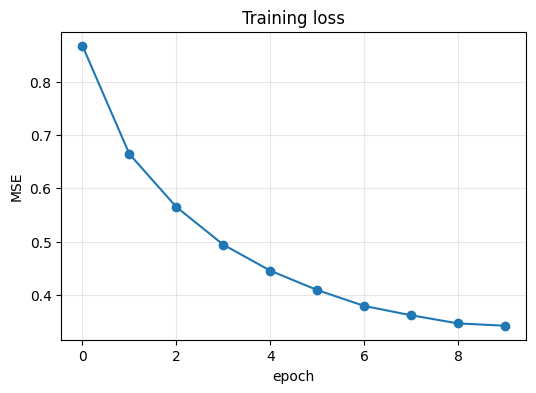

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history, marker="o")
plt.title("Training loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.grid(True, alpha=0.3)
plt.show()

## Part G. One learned denoising step on a held-out noisy example

This is the first important test.

We take a **new rectangle that the model did not memorize**, add noise to obtain $x_t$, and then let the network estimate the clean image.

To make the denoising effect visually clear for students, we show:

1. the true clean image $x_0$,
2. the noisy image $x_t$,
3. the network's raw estimate $\hat x_0$,
4. a clipped version of $\hat x_0$ for display,
5. a thresholded display-only version.

The thresholded image is **not** part of the diffusion formula; it is only a visual aid to show whether the recovered shape is correct.


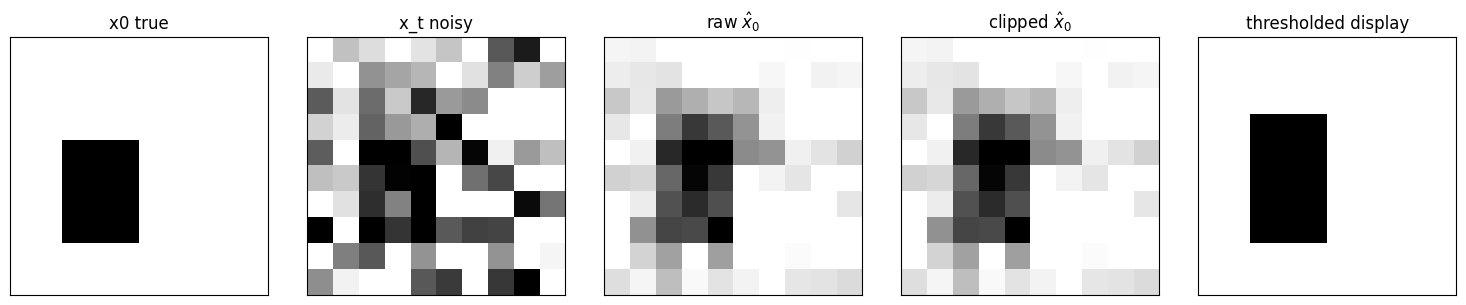

MSE(noisy image, x0)      = 0.2956
MSE(denoised estimate, x0)= 0.0375


In [ ]:
@torch.no_grad()
def predict_x0_from_noise_model(model, x0, t_index):
    model.eval()

    x0 = torch.tensor(x0, device=device).view(1, -1)
    t = torch.tensor([t_index], device=device, dtype=torch.long)
    true_noise = torch.randn_like(x0)
    a_bar = alpha_bars[t].unsqueeze(1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * true_noise

    pred_noise = model(xt, t)
    x0_hat = (xt - torch.sqrt(1 - a_bar) * pred_noise) / torch.sqrt(a_bar)
    x0_clip = torch.clamp(x0_hat, 0.0, 1.0)
    x0_thresh = (x0_clip > 0.5).float()

    mse_noisy = F.mse_loss(xt, x0).item()
    mse_denoised = F.mse_loss(x0_clip, x0).item()

    return (
        x0.view(GRID, GRID).cpu().numpy(),
        xt.view(GRID, GRID).cpu().numpy(),
        true_noise.view(GRID, GRID).cpu().numpy(),
        pred_noise.view(GRID, GRID).cpu().numpy(),
        x0_hat.view(GRID, GRID).cpu().numpy(),
        x0_clip.view(GRID, GRID).cpu().numpy(),
        x0_thresh.view(GRID, GRID).cpu().numpy(),
        mse_noisy,
        mse_denoised,
    )

x0_img = random_shape("rectangle")
(x0_true, xt_img, eps_true, eps_pred, x0_hat, x0_clip, x0_thresh,
 mse_noisy, mse_denoised) = predict_x0_from_noise_model(model, x0_img, t_index=8)

show_images(
    [x0_true, xt_img, x0_hat, x0_clip, x0_thresh],
    ["x0 true", "x_t noisy", r"raw $\hat{x}_0$", r"clipped $\hat{x}_0$", "thresholded display"],
    figsize=(15,3),
    vmin=0,
    vmax=1
)

print(f"MSE(noisy image, x0)      = {mse_noisy:.4f}")
print(f"MSE(denoised estimate, x0)= {mse_denoised:.4f}")

## Part H. Step-by-step learned denoising trajectory

Instead of starting from pure noise, we now demonstrate the **denoising algorithm itself**.

We begin from a noisy version of a clean rectangle at a large time index $t_{\text{start}}$.
Then we repeatedly apply the network to move toward earlier time levels:
$$
\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\,\varepsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}.
$$

For a simple deterministic classroom update, we then set
$$
x_{t-1}^{\text{demo}}
=
\sqrt{\bar\alpha_{t-1}}\,\hat x_0
+
\sqrt{1-\bar\alpha_{t-1}}\,\varepsilon_\theta(x_t,t).
$$

This is not meant to be a full production sampler. Its purpose is to let students **see the image become less noisy step by step**.


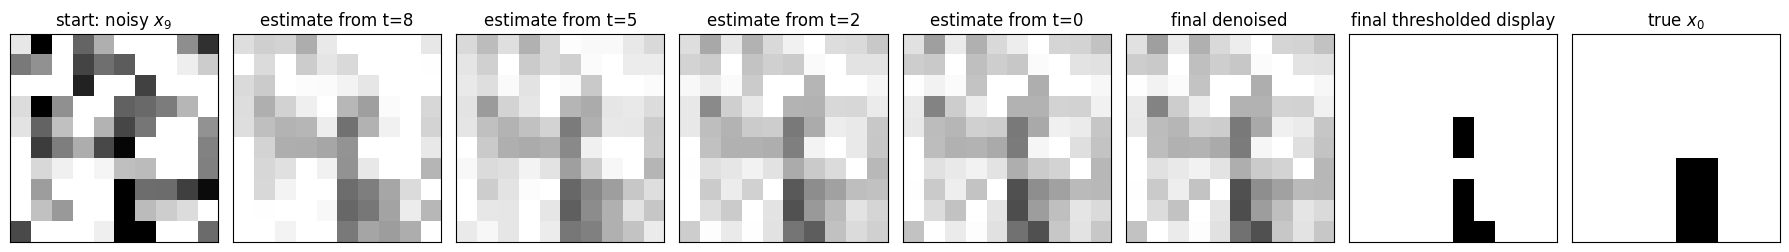

In [ ]:
@torch.no_grad()
def denoise_trajectory(model, x0, t_start=None, n_frames=6):
    model.eval()

    if t_start is None:
        t_start = T - 1

    x0 = torch.tensor(x0, device=device).view(1, -1)
    eps = torch.randn_like(x0)
    a_bar_start = alpha_bars[t_start].view(1, 1)
    x = torch.sqrt(a_bar_start) * x0 + torch.sqrt(1 - a_bar_start) * eps

    frames = [torch.clamp(x, 0.0, 1.0).view(GRID, GRID).cpu().numpy()]
    titles = [f"start: noisy $x_{{{t_start}}}$"]

    capture_times = set(np.linspace(t_start-1, 0, max(n_frames-2, 1), dtype=int).tolist())

    for i in range(t_start, -1, -1):
        t = torch.tensor([i], device=device, dtype=torch.long)
        a_bar_t = alpha_bars[i].view(1, 1)

        eps_pred = model(x, t)
        x0_hat = (x - torch.sqrt(1 - a_bar_t) * eps_pred) / torch.sqrt(a_bar_t)
        x0_hat = torch.clamp(x0_hat, 0.0, 1.0)

        if i in capture_times:
            frames.append(x0_hat.view(GRID, GRID).cpu().numpy())
            titles.append(f"estimate from t={i}")

        if i > 0:
            a_bar_prev = alpha_bars[i-1].view(1, 1)
            x = torch.sqrt(a_bar_prev) * x0_hat + torch.sqrt(1 - a_bar_prev) * eps_pred
        else:
            x = x0_hat

    x_final = torch.clamp(x, 0.0, 1.0)
    x_binary = (x_final > 0.5).float()

    frames.extend([
        x_final.view(GRID, GRID).cpu().numpy(),
        x_binary.view(GRID, GRID).cpu().numpy(),
        x0.view(GRID, GRID).cpu().numpy(),
    ])
    titles.extend(["final denoised", "final thresholded display", "true $x_0$"])

    return frames, titles

x0_demo = random_shape("rectangle")
frames, titles = denoise_trajectory(model, x0_demo, t_start=T-1, n_frames=6)
show_images(frames, titles, figsize=(18,3), vmin=0, vmax=1)

## Part I. Why the earlier pure-noise samples looked bad

If you start from **pure Gaussian noise** and ask a very small network to generate a clean image from scratch, the result may still look noisy.

That is normal in this toy notebook because:

- the model is very small,
- the dataset is tiny and synthetic,
- the training time is short,
- diffusion sampling from pure noise is harder than denoising a partially corrupted image.

So for teaching, the clearest demonstration is often:

1. start with a clean image,
2. add noise using the forward formula,
3. let the trained network denoise it,
4. compare the denoised estimate with the original.

After students understand that, you can discuss full reverse sampling from pure noise as a more advanced topic.


## Optional extensions

- Change `kind="rectangle"` to `kind="mixed"` after the basic denoising demo works.
- Increase the number of training epochs if the denoised output is still blurry.
- Add a final optional cell that attempts full generation from pure noise.
- Replace the MLP by a small convolutional network.
- Compare deterministic reverse updates with stochastic reverse updates.
